In [3]:
"""
Schwartz-Smith data preparation for Bloomberg EEX Phelix Base month futures.

Consumes the raw BDH dump and emits model-ready arrays for a linear Kalman
filter with geometric-delivery averaging and a mean-zero 2-harmonic seasonal.

Usage:  python clean_phelix.py RAW.csv OUTDIR
"""
import sys, json, csv
from pathlib import Path
from zoneinfo import ZoneInfo
from datetime import datetime, timedelta

import os
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.linalg import cho_factor, cho_solve
from dataclasses import dataclass, replace
import matplotlib.pyplot as plt
from scipy.stats import jarque_bera
import importlib, ss_flow
importlib.reload(ss_flow)
from ss_flow import load_window, seasonal_g

In [4]:
# --------------------------------------------------------------------------
# Configuration
# --------------------------------------------------------------------------
N_SLOTS        = 8            # contracts per date; 8 is dense, 9 fails on 7 dates
N_HARMONICS    = 3           # annual + semi-annual
DAY_COUNT      = 365.25
MAX_DELIV_DAYS = 31           # padding width for the delivery-day grid
LEAD_RUN_MAX   = 5            # leading constant run longer than this = phantom
RESAMPLE_DOW   = 2            # 2 = Wednesday; set None for daily
DROP_STALE     = False        # True -> delete flagged stale cells instead of flagging

WINDOWS = {
    "calm":  ("2018-01-01", "2021-06-30"),
    "post":  ("2023-01-01", "2026-12-31"),
    "full":  ("2018-01-01", "2026-12-31"),
}

NA_TOKENS = {"", "#N/A N/A", "#N/A Requesting Data...",
             "#N/A Field Not Applicable", "#N/A Invalid Security",
             "#N/A History", "#N/A"}

MONTH_CODE = {"F":1, "G":2, "H":3, "J":4, "K":5, "M":6,
              "N":7, "Q":8, "U":9, "V":10, "X":11, "Z":12}

BERLIN = ZoneInfo("Europe/Berlin")


In [5]:
# --------------------------------------------------------------------------
# Step 0-1: structural parse and coercion
# --------------------------------------------------------------------------
def _num(tok):
    tok = tok.strip()
    if tok in NA_TOKENS:
        return np.nan
    try:
        return float(tok)
    except ValueError:
        return np.nan


def parse_raw(path):
    rows = list(csv.reader(open(path, encoding="utf-8-sig")))

    # locate the field-header row (contains 'Dates' and 'PX_SETTLE')
    hdr_i = next(i for i, r in enumerate(rows)
                 if "Dates" in r and "PX_SETTLE" in r)
    date_col = rows[hdr_i].index("Dates")
    bann_i = next(i for i in range(hdr_i - 1, -1, -1)
                  if sum("Comdty" in c for c in rows[i][date_col:]) > 1)

    banner = rows[bann_i]
    triples = [(banner[j].strip(), j)
               for j in range(date_col + 1, len(banner), 3)
               if banner[j].strip()]
    for tk, j in triples:                     # assert the field ordering
        assert rows[hdr_i][j:j + 3] == ["PX_SETTLE", "PX_VOLUME", "OPEN_INT"], tk

    # metadata block: contiguous leading rows whose col 0 is a ticker
    meta = []
    for r in rows:
        if not r[0].strip().endswith("Comdty"):
            break
        meta.append(dict(ticker=r[0].strip(), delivery_start=r[1],
                         delivery_end=r[2], last_trade_date=r[3],
                         hours_bbg=int(r[4])))
    meta = pd.DataFrame(meta)
    for c in ("delivery_start", "delivery_end", "last_trade_date"):
        meta[c] = pd.to_datetime(meta[c], dayfirst=True, format="mixed")
    meta = meta.set_index("ticker")

    data = rows[hdr_i + 1:]
    dates = pd.to_datetime([r[date_col] for r in data],
                           dayfirst=True, format="mixed")
    mk = lambda off: pd.DataFrame(
        {tk: [_num(r[j + off]) for r in data] for tk, j in triples}, index=dates)
    return meta, mk(0), mk(1), mk(2)


In [6]:
# --------------------------------------------------------------------------
# Step 2: validation gates
# --------------------------------------------------------------------------
def delivery_hours(day):
    """Wall-clock hours in a Europe/Berlin calendar day (23 / 24 / 25)."""
    a = datetime(day.year, day.month, day.day, tzinfo=BERLIN)
    b = a + timedelta(days=1)
    return round((b.astimezone(ZoneInfo("UTC")) -
                  a.astimezone(ZoneInfo("UTC"))).total_seconds() / 3600)


def month_hour_vector(start, end):
    days = pd.date_range(start, end, freq="D")
    return np.array([delivery_hours(d) for d in days], float), days


def validate(meta, P):
    assert list(meta.index) == list(P.columns), "metadata/banner ticker mismatch"
    assert P.index.is_monotonic_increasing and not P.index.duplicated().any()
    assert (P.index.dayofweek < 5).all(), "weekend rows present"

    for tk, r in meta.iterrows():
        code = tk[3]
        assert r.delivery_start.month == MONTH_CODE[code], f"{tk} month code"
        assert r.delivery_start.day == 1
        assert r.delivery_end == r.delivery_start + pd.offsets.MonthEnd(0)
        assert r.last_trade_date <= r.delivery_end, f"{tk} LTD after delivery"
        h, _ = month_hour_vector(r.delivery_start, r.delivery_end)
        assert h.sum() == r.hours_bbg, f"{tk} hours {h.sum()} vs {r.hours_bbg}"

    v = P.to_numpy()
    assert np.nanmin(v) > 0, "non-positive price"
    return True

In [7]:
# --------------------------------------------------------------------------
# Steps 3-7: masks
# --------------------------------------------------------------------------
def apply_masks(meta, P, V, OI):
    log = {}
    idx = P.index

    # 4 post-expiry | 5 in-delivery
    alive = pd.DataFrame({t: (idx <= meta.last_trade_date[t]) &
                             (idx <  meta.delivery_start[t])
                          for t in P.columns}, index=idx)
    log["cells_total"]      = int(P.notna().to_numpy().sum())
    Pm = P.where(alive)
    log["cells_post_expiry_or_in_delivery"] = \
        log["cells_total"] - int(Pm.notna().to_numpy().sum())

    # 6 phantom leading constant run
    phantom = 0
    for t in Pm.columns:
        s = Pm[t].dropna()
        if len(s) < 2:
            continue
        v = s.to_numpy(); k = 1
        while k < len(v) and v[k] == v[0]:
            k += 1
        if k > LEAD_RUN_MAX:
            Pm.loc[s.index[:k], t] = np.nan
            phantom += k
    log["cells_phantom_lead_run"] = phantom

    # 3 exchange holidays: no alive contract moved
    d = Pm.diff().abs()
    hol = idx[((d > 0).sum(axis=1) == 0) & (Pm.notna().sum(axis=1) > 0)]
    log["dates_holiday_dropped"] = len(hol)
    log["holiday_dates"] = [str(x.date()) for x in hol]
    Pm, V, OI = Pm.drop(hol), V.drop(hol), OI.drop(hol)

    # 7 staleness flag
    stale = (Pm.ffill().diff() == 0) & Pm.notna() & V.isna()
    log["cells_stale_flagged"] = int(stale.to_numpy().sum())
    if DROP_STALE:
        Pm = Pm.mask(stale)
    log["cells_surviving"] = int(Pm.notna().to_numpy().sum())
    return Pm, V, OI, stale, log

In [8]:
# --------------------------------------------------------------------------
# Step 8: long panel with delivery geometry
# --------------------------------------------------------------------------
def build_long(meta, Pm, V, OI, stale):
    hv = {t: month_hour_vector(meta.delivery_start[t], meta.delivery_end[t])
          for t in Pm.columns}

    lp = (Pm.stack().dropna().rename("settle").reset_index()
            .rename(columns={"level_0": "trade_date", "level_1": "ticker"}))
    lp["volume"]        = [V.at[d, t]     for d, t in zip(lp.trade_date, lp.ticker)]
    lp["open_interest"] = [OI.at[d, t]    for d, t in zip(lp.trade_date, lp.ticker)]
    lp["stale_flag"]    = [stale.at[d, t] for d, t in zip(lp.trade_date, lp.ticker)]

    m = meta.loc[lp.ticker]
    lp["delivery_start"]  = m.delivery_start.to_numpy()
    lp["delivery_end"]    = m.delivery_end.to_numpy()
    lp["last_trade_date"] = m.last_trade_date.to_numpy()
    lp["delivery_hours"]  = m.hours_bbg.to_numpy()
    lp["delivery_month"]  = lp.delivery_start.dt.month

    lp["tau_start"] = (lp.delivery_start - lp.trade_date).dt.days / DAY_COUNT
    lp["tau_end"]   = (lp.delivery_end   - lp.trade_date).dt.days / DAY_COUNT
    lp["log_settle"] = np.log(lp.settle)

    # per-delivery-day grid u (years) and hour weights, padded
    n = len(lp)
    U = np.zeros((n, MAX_DELIV_DAYS)); W = np.zeros((n, MAX_DELIV_DAYS))
    for i, (t, tk) in enumerate(zip(lp.trade_date.to_numpy(), lp.ticker)):
        h, days = hv[tk]
        k = len(h)
        U[i, :k] = ((days.to_numpy() - t).astype("timedelta64[D]")
                    .astype(float) + 0.5) / DAY_COUNT
        W[i, :k] = h / h.sum()
    lp["tau_mid"] = (U * W).sum(1)
    return lp, U, W

In [9]:
# --------------------------------------------------------------------------
# Step 9: mean-zero 2-harmonic seasonal, delivery-averaged, date-FE absorbed
# --------------------------------------------------------------------------
def seasonal_basis(lp, U, W, n_harm=N_HARMONICS):
    """Hour-averaged cos/sin of the delivery period. phi = position in the year."""
    yr_start = pd.to_datetime(lp.trade_date.dt.year.astype(str) + "-01-01")
    doy0 = (lp.trade_date - yr_start).dt.days.to_numpy()[:, None] / DAY_COUNT
    phi = doy0 + U                              # calendar position of each del. day
    cols = []
    for j in range(1, n_harm + 1):
        cols.append((np.cos(2 * np.pi * j * phi) * W).sum(1))
        cols.append((np.sin(2 * np.pi * j * phi) * W).sum(1))
    names = sum([[f"cos{j}", f"sin{j}"] for j in range(1, n_harm + 1)], [])
    return np.column_stack(cols), names


def reference_offset(beta, n_harm=N_HARMONICS):
    """Mean of gbar over the 12 delivery months of a reference year.
    Pure harmonics integrate to zero over a year, so this is ~0; subtracting it
    makes the mean-zero normalisation exact rather than approximate."""
    rows = []
    for m in range(1, 13):
        st = pd.Timestamp(2019, m, 1); en = st + pd.offsets.MonthEnd(0)
        h, days = month_hour_vector(st, en)
        w = h / h.sum()
        phi = ((days - pd.Timestamp(2019, 1, 1)).days.to_numpy() + 0.5) / DAY_COUNT
        rows.append([f(2 * np.pi * j * phi) @ w
                     for j in range(1, n_harm + 1) for f in (np.cos, np.sin)])
    return float(np.mean(np.asarray(rows) @ beta))


def fit_seasonal(lp, X):
    """Frisch-Waugh: absorb date fixed effects by within-date demeaning."""
    y = lp.log_settle.to_numpy()
    g = lp.trade_date.to_numpy()
    df = pd.DataFrame(X); df["y"] = y; df["g"] = g
    dm = df.groupby("g").transform("mean")
    Xd = df[list(range(X.shape[1]))].to_numpy() - dm[list(range(X.shape[1]))].to_numpy()
    yd = y - dm["y"].to_numpy()
    beta, *_ = np.linalg.lstsq(Xd, yd, rcond=None)
    gbar = X @ beta - reference_offset(beta)               # exact mean-zero
    r2 = 1 - ((yd - Xd @ beta) ** 2).sum() / (yd ** 2).sum()
    return beta, gbar, r2

In [10]:
# --------------------------------------------------------------------------
# Step 10: fixed-slot rectangular panel
# --------------------------------------------------------------------------
def build_slots(lp, U, W, n_slots=N_SLOTS, dow=RESAMPLE_DOW):
    lp = lp.copy(); lp["_i"] = np.arange(len(lp))
    lp = lp.sort_values(["trade_date", "tau_start"])
    lp["slot"] = lp.groupby("trade_date").cumcount()

    dates = np.array(sorted(lp.trade_date.unique()))
    ok = np.array([(lp.trade_date == d).sum() >= n_slots for d in dates])
    dropped = [str(pd.Timestamp(d).date()) for d in dates[~ok]]
    dates = dates[ok]

    if dow is not None:                        # one date per ISO week
        dd = pd.DatetimeIndex(dates)
        iso = pd.DataFrame({"d": dd,
                            "wk": [(x.isocalendar().year, x.isocalendar().week)
                                   for x in dd]})
        pick = []
        for _, grp in iso.groupby("wk", sort=False):
            wed = grp[grp.d.dt.dayofweek == dow]
            pick.append((wed if len(wed) else grp).d.iloc[0 if len(wed) else -1])
        dates = np.array(sorted(pick))

    sub = lp[lp.trade_date.isin(dates) & (lp.slot < n_slots)]
    piv = lambda c: (sub.pivot(index="trade_date", columns="slot", values=c)
                        .loc[dates].to_numpy())
    ii = piv("_i").astype(int)
    out = dict(
        dates      = pd.DatetimeIndex(dates),
        y_raw      = piv("log_settle"),
        gbar       = piv("gbar"),
        y          = piv("log_settle") - piv("gbar"),
        tau_start  = piv("tau_start"),
        tau_end    = piv("tau_end"),
        tau_mid    = piv("tau_mid"),
        settle     = piv("settle"),
        volume     = piv("volume"),
        open_int   = piv("open_interest"),
        stale      = piv("stale_flag"),
        ticker     = sub.pivot(index="trade_date", columns="slot",
                               values="ticker").loc[dates].to_numpy(),
        U          = U[ii],
        W          = W[ii],
        dropped_sparse_dates = dropped,
    )
    dt = np.diff(out["dates"].to_numpy()).astype("timedelta64[D]").astype(float)
    out["dt"] = dt / DAY_COUNT
    return out

In [11]:
# --------------------------------------------------------------------------
# Driver
# --------------------------------------------------------------------------
def run(raw_path, outdir):
    outdir = Path(outdir); outdir.mkdir(parents=True, exist_ok=True)
    meta, P, V, OI = parse_raw(raw_path)
    validate(meta, P)
    Pm, V, OI, stale, log = apply_masks(meta, P, V, OI)
    lp, U, W = build_long(meta, Pm, V, OI, stale)

    report = {"raw_shape": [len(P), len(P.columns)],
              "date_range": [str(P.index[0].date()), str(P.index[-1].date())],
              "n_contracts": len(meta), "masks": log, "windows": {}}

    meta.reset_index().to_csv(outdir / "contracts.csv", index=False)

    for name, (a, b) in WINDOWS.items():
        sel = (lp.trade_date >= a) & (lp.trade_date <= b)
        sub = lp[sel].reset_index(drop=True)
        Us, Ws = U[sel.to_numpy()], W[sel.to_numpy()]

        X, names = seasonal_basis(sub, Us, Ws)
        beta, gbar, r2 = fit_seasonal(sub, X)
        sub["gbar"] = gbar

        d = build_slots(sub, Us, Ws)
        wd = outdir / name; wd.mkdir(exist_ok=True)
        for k in ("y", "y_raw", "gbar", "tau_start", "tau_end", "tau_mid",
                  "U", "W", "dt", "settle", "volume", "open_int"):
            np.save(wd / f"{k}.npy", np.asarray(d[k], float))
        np.save(wd / "stale.npy", np.asarray(d["stale"], bool))
        np.save(wd / "dates.npy", d["dates"].to_numpy())
        pd.DataFrame(d["ticker"], index=d["dates"]).to_csv(wd / "tickers.csv")
        sub.drop(columns=[c for c in ("_i",) if c in sub]) \
           .to_csv(wd / "panel_long.csv", index=False)

        report["windows"][name] = {
            "range": [a, b], "n_dates": len(d["dates"]), "n_slots": N_SLOTS,
            "seasonal_coef": dict(zip(names, np.round(beta, 5).tolist())),
            "seasonal_partial_r2": round(float(r2), 4),
            "seasonal_by_delivery_month": {
                int(m): round(float(v), 4) for m, v in
                sub.groupby("delivery_month").gbar.mean().items()},
            "seasonal_amplitude_logpts": round(float(d["gbar"].max() - d["gbar"].min()), 4),
            "tau_min": round(float(d["tau_start"].min()), 4),
            "tau_max": round(float(d["tau_end"].max()), 4),
            "dt_mean": round(float(d["dt"].mean()), 5),
            "dt_unique_days": sorted({round(x * DAY_COUNT) for x in d["dt"]}),
            "y_has_nan": bool(np.isnan(d["y"]).any()),
            "stale_cells": int(d["stale"].sum()),
            "dropped_sparse_dates": d["dropped_sparse_dates"],
        }

    json.dump(report, open(outdir / "qc_report.json", "w"), indent=2)
    return report

In [12]:
# Entry point. In a notebook there are no CLI positional args (sys.argv is the
# kernel's own launcher line), so fall back to these defaults.
RAW_PATH = "GERMAN_POWER_EXCHANGE.csv"
OUT_DIR  = "prepped"

if __name__ == "__main__":
    args = sys.argv[1:]
    raw, out = (args[0], args[1]) if len(args) >= 2 else (RAW_PATH, OUT_DIR)

    rep = run(raw, out)
    print(json.dumps({k: v for k, v in rep.items() if k != "masks"}, indent=2)[:4000])
    print("\nMASKS:", json.dumps({k: v for k, v in rep["masks"].items()
                                  if k != "holiday_dates"}, indent=2))

{
  "raw_shape": [
    2242,
    120
  ],
  "date_range": [
    "2018-01-01",
    "2026-08-04"
  ],
  "n_contracts": 120,
  "windows": {
    "calm": {
      "range": [
        "2018-01-01",
        "2021-06-30"
      ],
      "n_dates": 183,
      "n_slots": 8,
      "seasonal_coef": {
        "cos1": 0.1026,
        "sin1": -0.02683,
        "cos2": 0.01278,
        "sin2": 0.02358,
        "cos3": -0.03639,
        "sin3": 0.02018
      },
      "seasonal_partial_r2": 0.6249,
      "seasonal_by_delivery_month": {
        "1": 0.1025,
        "2": 0.1123,
        "3": 0.0167,
        "4": -0.1073,
        "5": -0.1252,
        "6": -0.0716,
        "7": -0.0591,
        "8": -0.0672,
        "9": -0.0121,
        "10": 0.0647,
        "11": 0.0779,
        "12": 0.0676
      },
      "seasonal_amplitude_logpts": 0.239,
      "tau_min": 0.0027,
      "tau_max": 0.7502,
      "dt_mean": 0.01916,
      "dt_unique_days": [
        5,
        7,
        9
      ],
      "y_has_nan": false,

In [13]:
WINDOWS = {
    "calm":   ("2018-01-01", "2021-06-30"),
    "post":   ("2023-01-01", "2026-12-31"),
    "full":   ("2018-01-01", "2026-12-31"),
    "crisis": ("2021-07-01", "2022-12-31"),   # if you want it isolated
}

In [14]:
@dataclass(frozen=True)
class Params:
    """Field order follows Table 2's row order."""
    kappa: float; sigma_chi: float; lambda_chi: float
    mu_xi: float;  sigma_xi: float;  mu_xi_star: float; rho: float

    @property
    def lambda_xi(self):  return self.mu_xi - self.mu_xi_star
    @property
    def premia(self):     return (self.lambda_chi, self.lambda_xi)
    @property
    def half_life(self):  return np.log(2)/self.kappa

In [15]:
def cov(t, p):
    """Cov[(chi_t, xi_t)] -- Eq (3b). Identical under both measures, Eq (8b)."""
    v_chi = (1 - np.exp(-2*p.kappa*t)) * p.sigma_chi**2 / (2*p.kappa)
    v_xi  = p.sigma_xi**2 * t
    c     = (1 - np.exp(-p.kappa*t)) * p.rho * p.sigma_chi * p.sigma_xi / p.kappa
    return np.array([[v_chi, c], [c, v_xi]])

In [16]:
def A(T, p):
    """A(T) of Eq (9), written out."""
    T = np.asarray(T, float)
    k = p.kappa
    drift_part = p.mu_xi_star*T - (1 - np.exp(-k*T))*p.lambda_chi/k
    convexity  = 0.5*((1 - np.exp(-2*k*T))*p.sigma_chi**2/(2*k)
                      + p.sigma_xi**2*T
                      + 2*(1 - np.exp(-k*T))*p.rho*p.sigma_chi*p.sigma_xi/k)
    return drift_part + convexity

In [17]:
# --------------------------------------------------------------------------
# Window loader
# --------------------------------------------------------------------------
ARRAYS = ("y", "y_raw", "gbar", "tau_start", "tau_end", "tau_mid",
          "U", "W", "dt", "settle", "volume", "open_int", "stale")


def load_window(path):
    """Read one prepared window directory, e.g. load_window('prepped/calm').

    Returns a dict with the .npy arrays keyed by name, plus
      dates    DatetimeIndex, (n_T,)
      tickers  DataFrame indexed by date, (n_T, n_slots)
    """
    wd = Path(path)
    if not wd.is_dir():
        near = sorted(q.name for q in Path(wd.parent if wd.parent.name else ".")
                      .glob("*") if q.is_dir())
        raise FileNotFoundError(
            f"no window at {wd} -- run the prep driver first. "
            f"Directories beside it: {near}")

    D = {k: np.load(wd / f"{k}.npy") for k in ARRAYS if (wd / f"{k}.npy").exists()}
    D["dates"]   = pd.DatetimeIndex(np.load(wd / "dates.npy", allow_pickle=False))
    D["tickers"] = pd.read_csv(wd / "tickers.csv", index_col=0, parse_dates=True)

    n_T, n = D["y"].shape
    assert D["dt"].shape == (n_T - 1,), "dt must hold the n_T-1 step lengths"
    assert D["U"].shape[:2] == (n_T, n) and D["W"].shape == D["U"].shape
    assert len(D["dates"]) == n_T and D["tickers"].shape == (n_T, n)
    return D

In [18]:
WINDOW      = 'prepped/calm'
N_DIFFUSE   = 1        # m0 is built from y[0]; skip t=0 to avoid double-counting
C0_XI       = 1.0      # diffuse xi prior (sd 1 in log space); set 1e6 for flat
S_MIN       = 1e-4     # floor on measurement-error sd, keeps log s finite
N_STARTS    = 1        # >1 jitters theta0 and keeps the best optimum
SEED        = 0

# --------------------------------------------------------------------------
# PRECOMPUTE  (once, before optimization)
# --------------------------------------------------------------------------
D      = load_window(WINDOW)
y      = D['y']                       # (n_T, n) deseasonalised log futures
U, W   = D['U'], D['W']               # (n_T, n, 31) delivery times + hour weights
dtv    = D['dt']                      # (n_T-1,) actual step lengths in years
dates  = D['dates']
tau    = D['tau_mid']
n_T, n = y.shape
TICK   = D['tickers'].to_numpy()

DT_KEY = np.concatenate([[0.0], dtv])          # DT_KEY[t] = step into t
DT_UNQ = np.unique(DT_KEY[N_DIFFUSE:])         # a handful of distinct dt values
Upos   = np.where(W > 0, U, 1.0)               # padding -> harmless argument

# --- parameter vector: 7 structural + n measurement sds -------------------
PNAMES = ['kappa','sigma_chi','lambda_chi','mu_xi','sigma_xi','mu_xi_star','rho']
LOGIDX = [0, 1, 4]                             # log-transformed structural pars

def untransform(th):
    z = np.asarray(th, float)
    v = z.copy()
    v[LOGIDX] = np.exp(z[LOGIDX])
    v[6]      = np.tanh(z[6])
    p = Params(*v[:7])
    s = S_MIN + np.exp(z[7:])
    return p, s

def transform(p, s):
    v = np.array([p.kappa, p.sigma_chi, p.lambda_chi, p.mu_xi,
                  p.sigma_xi, p.mu_xi_star, p.rho], float)
    v[LOGIDX] = np.log(v[LOGIDX]); v[6] = np.arctanh(v[6])
    return np.concatenate([v, np.log(np.maximum(s - S_MIN, 1e-12))])

# --------------------------------------------------------------------------
# theta0  <-  method of moments on the futures volatility term structure
#   Var[dlnF(tau)]/dt = e^{-2*k*tau} sx^2 + sxi^2 + 2 e^{-k*tau} rho sx sxi
# --------------------------------------------------------------------------
def mom_seed():
    same = TICK[1:] == TICK[:-1]                       # exclude roll jumps
    r    = np.diff(y, axis=0) / np.sqrt(dtv)[:, None]
    v    = np.array([np.nanvar(np.where(same[:, i], r[:, i], np.nan))
                     for i in range(n)])
    tb   = tau.mean(0)
    def obj(q):
        k, sx, sxi, rho = np.exp(q[0]), np.exp(q[1]), np.exp(q[2]), np.tanh(q[3])
        m = np.exp(-2*k*tb)*sx**2 + sxi**2 + 2*np.exp(-k*tb)*rho*sx*sxi
        return np.sum((m - v)**2)
    q = minimize(obj, [np.log(1.0), np.log(0.3), np.log(0.15), 0.0],
                 method='Nelder-Mead',
                 options=dict(maxiter=8000, xatol=1e-10, fatol=1e-12)).x
    k, sx, sxi, rho = np.exp(q[0]), np.exp(q[1]), np.exp(q[2]), np.tanh(q[3])

    G       = np.column_stack([np.ones(n), tau.mean(0)])   # slope ~ mu_xi_star
    mu_star = np.linalg.lstsq(G, y.mean(0), rcond=None)[0][1]
    p0      = Params(k, sx, 0.0, mu_star, sxi, mu_star, rho)

    X   = np.stack([np.exp(-k*tau), np.ones_like(tau)], -1)   # per-date 2-factor OLS
    res = np.array([y[t] - X[t] @ np.linalg.lstsq(X[t], y[t] - A(tau[t], p0),
                                                  rcond=None)[0] - A(tau[t], p0)
                    for t in range(n_T)])
    return p0, np.maximum(res.std(0), 1e-3)

# --------------------------------------------------------------------------
# OUTER LOOP objective:  theta -> scalar l(theta)
# --------------------------------------------------------------------------
def kalman(th, store=False):
    p, s = untransform(th)
    if not (np.isfinite(th).all() and p.kappa > 1e-8 and abs(p.rho) < 0.999):
        return np.inf

    # -- t-invariant blocks: one (c, T, Q) per distinct step length ---------
    k, sx, sxi, rho = p.kappa, p.sigma_chi, p.sigma_xi, p.rho
    TQ = {}
    for dt in DT_UNQ:
        e  = np.exp(-k*dt)
        Q  = np.array([[(1-e**2)*sx**2/(2*k), (1-e)*rho*sx*sxi/k],
                       [(1-e)*rho*sx*sxi/k,   sxi**2*dt]])
        TQ[dt] = (np.array([0.0, p.mu_xi*dt]), np.diag([e, 1.0]), Q)

    # -- Z, d on the full delivery grid (vectorised, geometric averaging) ---
    Zc = (W * np.exp(-k*Upos)).sum(-1)
    d  = (W * A(Upos, p)).sum(-1)
    Z  = np.stack([Zc, np.ones_like(Zc)], -1)          # (n_T, n, 2)
    H  = np.diag(s**2)

    # -- m0, C0: stationary chi, diffuse xi ---------------------------------
    m = np.array([0.0, float(np.mean(y[0] - d[0]))])
    C = np.diag([sx**2/(2*k), C0_XI])

    ll, I2 = 0.0, np.eye(2)
    if store:
        aS, RS, mS, CS = (np.zeros((n_T, 2)), np.zeros((n_T, 2, 2)),
                          np.zeros((n_T, 2)), np.zeros((n_T, 2, 2)))

    # ---------------- INNER LOOP  t = 1..T  (pure recursion) --------------
    for t in range(n_T):
        if t == 0:
            a, R = m, C                                  # prior at the first date
        else:                                            # predict
            c, Tm, Q = TQ[DT_KEY[t]]
            a = c + Tm @ m
            R = Tm @ C @ Tm.T + Q

        Zt  = Z[t]                                       # forecast
        ZR  = Zt @ R                                     # (n, 2)
        v   = y[t] - (d[t] + Zt @ a)
        F   = ZR @ Zt.T + H
        F   = 0.5*(F + F.T)
        try:
            cf = cho_factor(F, lower=True)
        except np.linalg.LinAlgError:
            return np.inf

        if t >= N_DIFFUSE:                               # accumulate
            ll += (n*np.log(2*np.pi) + 2*np.log(np.diag(cf[0])).sum()
                   + v @ cho_solve(cf, v))

        K = cho_solve(cf, ZR).T                          # update  (2, n)
        m = a + K @ v
        J = I2 - K @ Zt
        C = J @ R @ J.T + K @ H @ K.T                    # Joseph form
        C = 0.5*(C + C.T)
        if store:
            aS[t], RS[t], mS[t], CS[t] = a, R, m, C

    if not np.isfinite(ll):
        return np.inf
    return (aS, RS, mS, CS, Z, d, 0.5*ll) if store else 0.5*ll

# --------------------------------------------------------------------------
# OUTER LOOP:  Nelder-Mead, then L-BFGS-B
# --------------------------------------------------------------------------
p0, s0 = mom_seed()
th0    = transform(p0, s0)
print('MoM seed :', {k: round(v, 4) for k, v in zip(PNAMES, [p0.kappa, p0.sigma_chi,
      p0.lambda_chi, p0.mu_xi, p0.sigma_xi, p0.mu_xi_star, p0.rho])})
print('           s0 =', np.round(s0, 4), '\n  l(theta0) = %.3f' % kalman(th0))

rng, best = np.random.default_rng(SEED), None
for j in range(N_STARTS):
    st = th0 if j == 0 else th0 + rng.normal(0, 0.25, th0.size)
    r1 = minimize(kalman, st, method='Nelder-Mead',
                  options=dict(maxiter=20000, maxfev=20000,
                               xatol=1e-8, fatol=1e-8, adaptive=True))
    r2 = minimize(kalman, r1.x, method='L-BFGS-B',
                  options=dict(maxiter=5000, maxfun=50000, ftol=1e-12, gtol=1e-10))
    r  = r2 if r2.fun <= r1.fun else r1
    print(f'  start {j}: NM {r1.fun:12.4f} -> BFGS {r2.fun:12.4f}')
    if best is None or r.fun < best.fun:
        best = r

th_hat        = best.x
p_hat, s_hat  = untransform(th_hat)
print('\nconverged  -log L = %.4f   (%s)' % (best.fun, best.message))

# --------------------------------------------------------------------------
# POST-ESTIMATION (once)
# --------------------------------------------------------------------------
aS, RS, mS, CS, Zh, dh, nll = kalman(th_hat, store=True)

# --- RTS smoother -> chi_{t|T}, xi_{t|T} ---------------------------------
ms, Cs = mS.copy(), CS.copy()
for t in range(n_T - 2, -1, -1):
    _, Tm, _ = (np.array([0., p_hat.mu_xi*DT_KEY[t+1]]),
                np.diag([np.exp(-p_hat.kappa*DT_KEY[t+1]), 1.0]), None)
    Jt      = CS[t] @ Tm.T @ np.linalg.inv(RS[t+1])
    ms[t]   = mS[t] + Jt @ (ms[t+1] - aS[t+1])
    Cs[t]   = CS[t] + Jt @ (Cs[t+1] - RS[t+1]) @ Jt.T
chi_s, xi_s = ms[:, 0], ms[:, 1]

# --- numerical Hessian -> standard errors (delta method) -----------------
def hessian(fun, x, h=1e-4):
    k = x.size; Hm = np.zeros((k, k)); f0 = fun(x)
    for i in range(k):
        for j in range(i, k):
            ei = np.zeros(k); ei[i] = h
            ej = np.zeros(k); ej[j] = h
            if i == j:
                Hm[i, i] = (fun(x+ei) - 2*f0 + fun(x-ei)) / h**2
            else:
                Hm[i, j] = Hm[j, i] = (fun(x+ei+ej) - fun(x+ei-ej)
                                       - fun(x-ei+ej) + fun(x-ei-ej)) / (4*h*h)
    return Hm

Hs   = hessian(kalman, th_hat)
Vth  = np.linalg.pinv(0.5*(Hs + Hs.T))
se_t = np.sqrt(np.clip(np.diag(Vth), 0, None))
jac  = np.ones(th_hat.size)                       # d(param)/d(theta), elementwise
jac[LOGIDX] = np.exp(th_hat[LOGIDX])
jac[6]      = 1 - np.tanh(th_hat[6])**2
jac[7:]     = np.exp(th_hat[7:])
se = se_t * np.abs(jac)

est = np.array([p_hat.kappa, p_hat.sigma_chi, p_hat.lambda_chi, p_hat.mu_xi,
                p_hat.sigma_xi, p_hat.mu_xi_star, p_hat.rho])
tbl = pd.DataFrame({'estimate': np.round(np.r_[est, s_hat], 5),
                    'std_error': np.round(se, 5)},
                   index=PNAMES + [f's_{i+1}' for i in range(n)])
tbl['t'] = np.round(tbl.estimate / tbl.std_error.replace(0, np.nan), 2)
print('\n', tbl.to_string())
print('\nhalf-life of chi : %.3f yr (%.1f months)'
      % (p_hat.half_life, p_hat.half_life*12))
print('lambda_xi = mu_xi - mu_xi_star = %.5f' % p_hat.lambda_xi)
print('eigenvalue range of Hessian: %.3e .. %.3e'
      % (np.linalg.eigvalsh(Hs).min(), np.linalg.eigvalsh(Hs).max()))

MoM seed : {'kappa': np.float64(3.997), 'sigma_chi': np.float64(0.3276), 'lambda_chi': 0.0, 'mu_xi': np.float64(0.1439), 'sigma_xi': np.float64(0.2817), 'mu_xi_star': np.float64(0.1439), 'rho': np.float64(0.7412)}
           s0 = [0.0254 0.0337 0.0345 0.036  0.0304 0.0307 0.0321 0.0283] 
  l(theta0) = -2385.888
  start 0: NM   -2526.6431 -> BFGS   -2526.6431

converged  -log L = -2526.6431   (ABNORMAL: )

             estimate  std_error      t
kappa        3.41721    0.32847  10.40
sigma_chi    0.35677    0.03373  10.58
lambda_chi  -0.36299    0.19712  -1.84
mu_xi        0.21565    0.11361   1.90
sigma_xi     0.21198    0.01657  12.79
mu_xi_star  -0.02798    0.02105  -1.33
rho          0.52229    0.11431   4.57
s_1          0.04524    0.00372  12.16
s_2          0.03564    0.00263  13.55
s_3          0.03534    0.00224  15.78
s_4          0.03990    0.00234  17.05
s_5          0.03330    0.00206  16.17
s_6          0.03349    0.00210  15.95
s_7          0.03557    0.00225  15.81
s_8  

        tau_med  mean_err   sd_err      mae    s_hat  std_innov_sd   acf1  LB(10)
slot 1    0.084  -0.00092  0.07197  0.05526  0.04524         0.940  0.237    32.1
slot 2    0.167   0.00101  0.06328  0.05077  0.03564         1.073  0.547   149.5
slot 3    0.251   0.00083  0.05499  0.04206  0.03534         1.005  0.493    79.9
slot 4    0.335  -0.00264  0.05401  0.04324  0.03990         0.972  0.560   195.7
slot 5    0.418   0.00001  0.05256  0.03960  0.03330         0.957  0.478   139.3
slot 6    0.502   0.00077  0.05066  0.03999  0.03349         1.046  0.590   137.8
slot 7    0.585  -0.00202  0.05307  0.04109  0.03557         0.968  0.662   169.5
slot 8    0.668   0.00026  0.04477  0.03577  0.02791         1.027  0.551   172.1 
  LB(10) 95% critical value = 18.31
Jarque-Bera on pooled standardised innovations: stat=8.7  p=0.0128
cross-slot corr of std innovations (max |off-diag|) = 0.388
residual seasonal R^2 (should be ~0): 0.0010


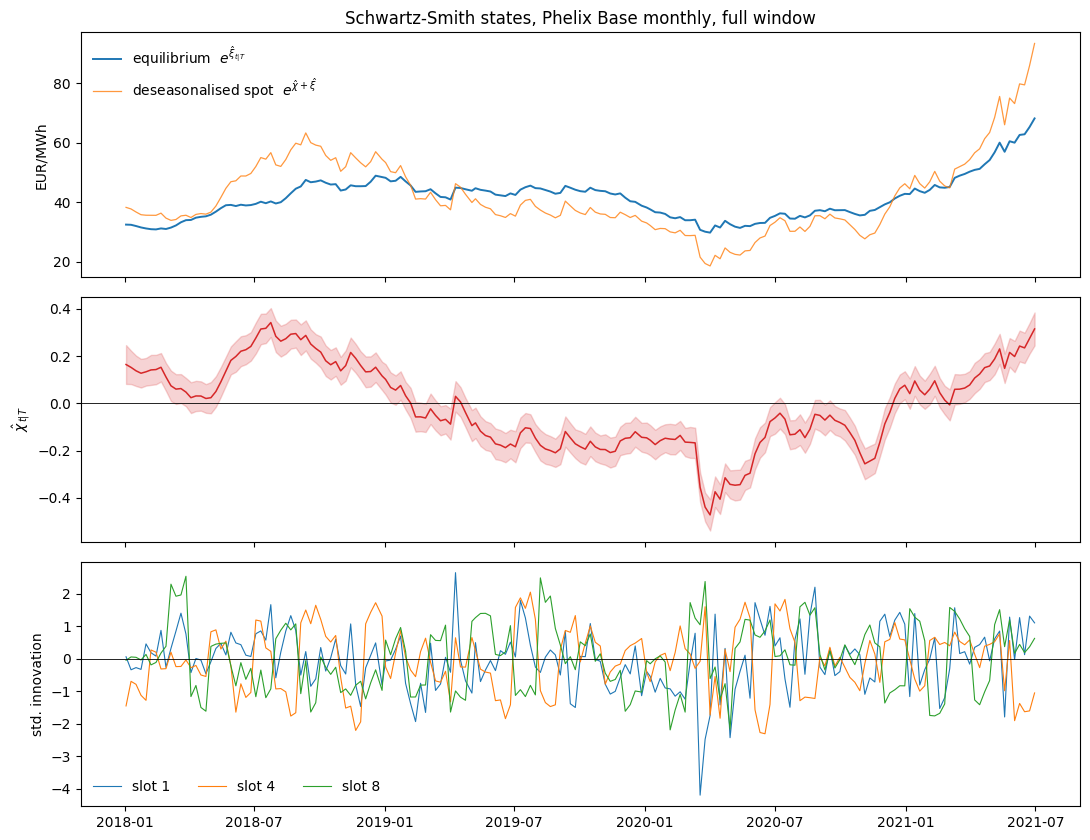

In [26]:
# Paste as a notebook cell. Requires Params (cell 1) and A(T, p) (cell 6).
# ===========================================================================
# CELL: post-estimation diagnostics + state plot   (run after the KF+MLE cell)
# ===========================================================================
p, s = p_hat, s_hat
Zc   = (W * np.exp(-p.kappa*Upos)).sum(-1)
dg   = (W * A(Upos, p)).sum(-1)

# one-step-ahead innovations and their standardised form
V  = np.zeros((n_T, n)); E = np.zeros((n_T, n))
for t in range(n_T):
    Zt = np.stack([Zc[t], np.ones(n)], -1)
    F  = Zt @ RS[t] @ Zt.T + np.diag(s**2)
    V[t] = y[t] - (dg[t] + Zt @ aS[t])
    E[t] = np.linalg.solve(np.linalg.cholesky(0.5*(F + F.T)), V[t])

def lb(x, m=10):                                  # Ljung-Box Q
    N = len(x); x = x - x.mean()
    r = np.array([np.corrcoef(x[:-k], x[k:])[0, 1] for k in range(1, m+1)])
    return N*(N+2)*np.sum(r**2/(N - np.arange(1, m+1)))

diag = pd.DataFrame({
    'tau_med'   : np.round(np.median(tau, 0), 3),
    'mean_err'  : np.round(V.mean(0), 5),
    'sd_err'    : np.round(V.std(0), 5),
    'mae'       : np.round(np.abs(V).mean(0), 5),
    's_hat'     : np.round(s, 5),
    'std_innov_sd': np.round(E[N_DIFFUSE:].std(0), 3),
    'acf1'      : np.round([np.corrcoef(E[N_DIFFUSE:-1, i], E[N_DIFFUSE+1:, i])[0, 1]
                            for i in range(n)], 3),
    'LB(10)'    : np.round([lb(E[N_DIFFUSE:, i]) for i in range(n)], 1),
}, index=[f'slot {i+1}' for i in range(n)])
print(diag.to_string(), '\n  LB(10) 95% critical value = 18.31')
print('Jarque-Bera on pooled standardised innovations: stat=%.1f  p=%.4f'
      % jarque_bera(E[N_DIFFUSE:].ravel())[:2])
print('cross-slot corr of std innovations (max |off-diag|) = %.3f'
      % np.abs(np.corrcoef(E[N_DIFFUSE:].T) - np.eye(n)).max())

# leftover seasonality check: regress pooled innovations on delivery-month harmonics
phi = ((tau*0 + np.array([[pd.Timestamp(x).dayofyear for x in
        np.repeat(dates.to_numpy(), n)]]).reshape(n_T, n))/365.25 + tau)
Xh  = np.column_stack([f(2*np.pi*j*phi.ravel())
                       for j in (1, 2) for f in (np.cos, np.sin)])
b, *_ = np.linalg.lstsq(np.c_[np.ones(Xh.shape[0]), Xh], V.ravel(), rcond=None)
r2 = 1 - ((V.ravel() - np.c_[np.ones(Xh.shape[0]), Xh] @ b)**2).sum()/((V.ravel()-V.mean())**2).sum()
print('residual seasonal R^2 (should be ~0): %.4f' % r2)

fig, ax = plt.subplots(3, 1, figsize=(11, 8.5), sharex=True)
ax[0].plot(dates, np.exp(xi_s), lw=1.4, label=r'equilibrium  $e^{\hat\xi_{t|T}}$')
ax[0].plot(dates, np.exp(chi_s + xi_s), lw=0.9, alpha=.8,
           label=r'deseasonalised spot  $e^{\hat\chi+\hat\xi}$')
ax[0].set_ylabel('EUR/MWh'); ax[0].legend(frameon=False); ax[0].set_title(
    f'Schwartz-Smith states, Phelix Base monthly, {WINDOW.split("/")[-1]} window')
ax[1].plot(dates, chi_s, lw=1.1, color='C3')
ax[1].fill_between(dates, chi_s-1.96*np.sqrt(Cs[:, 0, 0]),
                   chi_s+1.96*np.sqrt(Cs[:, 0, 0]), alpha=.2, color='C3')
ax[1].axhline(0, color='k', lw=.6); ax[1].set_ylabel(r'$\hat\chi_{t|T}$')
ax[2].plot(dates, E[:, [0, 3, 7]], lw=.8)
ax[2].axhline(0, color='k', lw=.6); ax[2].set_ylabel('std. innovation')
ax[2].legend(['slot 1', 'slot 4', 'slot 8'], frameon=False, ncol=3)
plt.tight_layout(); 
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/states_and_innovations.png.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [20]:
# ===========================================================================
# CELL: P- and Q-measure state processes, spot moments, risk premium, Figure 1
# Run after the KF+MLE cell.  Uses p_hat and the smoothed states.
# Notation: notebook field  sigma_chi <-> your sigma_X   (short-term deviation)
#                           sigma_xi  <-> your sigma_chi (equilibrium level)
# ===========================================================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import norm
sys.path.insert(0, 'phelix'); from ss_flow import seasonal_g
 
HORIZON      = 3.0          # years; mu_xi is large on this window, see note
STATE_UNC    = True         # augment with the smoother's C_T (paper p.903)
ANCHOR       = -1           # index of the date the forecast starts from
 
p   = p_hat
t0  = dates[ANCHOR]
X0, CHI0 = chi_s[ANCHOR], xi_s[ANCHOR]        # X = short-term, CHI = equilibrium
Chat     = Cs[ANCHOR] if STATE_UNC else np.zeros((2, 2))
gfun, _, _ = seasonal_g('prepped/qc_report.json', WINDOW.split('/')[-1], n_harm=3) 
# --------------------------------------------------------------------------
# 1) covariance matrix of (X_t, CHI_t)  -- Eq (3b), identical under P and Q
# --------------------------------------------------------------------------
def state_cov(t, p, Chat=np.zeros((2, 2))):
    t = np.atleast_1d(np.asarray(t, float))
    k, sx, sc, r = p.kappa, p.sigma_chi, p.sigma_xi, p.rho
    e = np.exp(-k*t)
    V = np.empty((t.size, 2, 2))
    V[:, 0, 0] = (1 - e**2)*sx**2/(2*k)          + e**2*Chat[0, 0]
    V[:, 0, 1] = V[:, 1, 0] = (1 - e)*r*sx*sc/k  + e   *Chat[0, 1]
    V[:, 1, 1] = sc**2*t                         +      Chat[1, 1]
    return V
 
# --------------------------------------------------------------------------
# 2) the two processes.  P:  dX = -kappa X dt + sx dz_X ,  dCHI = mu dt + sc dz
#    Q:  dX = (-kappa X - lam_X) dt ,       dCHI = (mu - lam_CHI) dt
#    Exact discretisation, so the recursion is not an Euler approximation:
#       X_i   = e^{-kappa*h} X_{i-1} + drift_Q + eps_X
#       CHI_i = CHI_{i-1} + mu*h + eps_CHI ,   (eps_X, eps_CHI) ~ N(0, Cov(h))
# --------------------------------------------------------------------------
def state_mean(t, p, X0, CHI0, measure='P'):
    t = np.atleast_1d(np.asarray(t, float))
    k, e = p.kappa, np.exp(-p.kappa*np.atleast_1d(t))
    if measure == 'P':
        return np.column_stack([e*X0, CHI0 + p.mu_xi*t])
    return np.column_stack([e*X0 - (1 - e)*p.lambda_chi/k,
                            CHI0 + p.mu_xi_star*t])           # mu* = mu - lam_CHI
 
def simulate(p, X0, CHI0, h, n_step, n_path, measure='P', seed=0):
    rng = np.random.default_rng(seed)
    V   = state_cov(h, p)[0]
    L   = np.linalg.cholesky(V)
    e   = np.exp(-p.kappa*h)
    mu  = p.mu_xi if measure == 'P' else p.mu_xi_star
    dq  = 0.0 if measure == 'P' else -(1 - e)*p.lambda_chi/p.kappa
    X   = np.empty((n_step+1, n_path)); C = np.empty_like(X)
    X[0], C[0] = X0, CHI0
    for i in range(1, n_step+1):
        z = L @ rng.standard_normal((2, n_path))
        X[i] = e*X[i-1] + dq + z[0]
        C[i] = C[i-1] + mu*h + z[1]
    return X, C
 
# --------------------------------------------------------------------------
# 3) moments of ln S_t -- Eq (4a)/(4b) under P, Eq (8a)/(8b) under Q
# --------------------------------------------------------------------------
def logspot_moments(t, p, X0, CHI0, measure='P', Chat=np.zeros((2, 2))):
    m = state_mean(t, p, X0, CHI0, measure).sum(1)
    V = state_cov(t, p, Chat)
    return m, V[:, 0, 0] + V[:, 1, 1] + 2*V[:, 0, 1]
 
# 4) ln E[S_t] = E[ln S_t] + 1/2 Var[ln S_t]  -- Eq (5)
def log_expected_spot(t, p, X0, CHI0, measure='P', Chat=np.zeros((2, 2))):
    m, v = logspot_moments(t, p, X0, CHI0, measure, Chat)
    return m + 0.5*v
 
def risk_premium(t, p):
    """E[ln S_t] - E*[ln S_t] = (1-e^{-kt}) lam_X / kappa + lam_CHI t."""
    t = np.atleast_1d(np.asarray(t, float))
    return (1 - np.exp(-p.kappa*t))*p.lambda_chi/p.kappa + p.lambda_xi*t
 
# ---- self-tests ----------------------------------------------------------
_t = np.array([0.25, 1.0, 3.0])
assert np.allclose(logspot_moments(_t, p, X0, CHI0, 'P')[0]
                   - logspot_moments(_t, p, X0, CHI0, 'Q')[0], risk_premium(_t, p))
assert np.allclose(logspot_moments(_t, p, X0, CHI0, 'P')[1],
                   logspot_moments(_t, p, X0, CHI0, 'Q')[1])   # Var* = Var, Eq (8b)
assert np.allclose(log_expected_spot(_t, p, X0, CHI0, 'Q'),
                   np.exp(-p.kappa*_t)*X0 + CHI0 + A(_t, p))   # ties to Eq (9)
Xs, Cq = simulate(p, X0, CHI0, 1/252, 252, 40000, 'P', seed=1)
assert abs((Xs[-1]+Cq[-1]).mean() - logspot_moments([1.0], p, X0, CHI0, 'P')[0][0]) < 0.02
print('self-tests passed:  RP identity, Var*=Var, Eq(9) tie-out, MC vs analytic')
 
print('\nanchor %s   X_0 = %+.4f   CHI_0 = %+.4f   deseasonalised spot = %.2f EUR/MWh'
      % (t0.date(), X0, CHI0, np.exp(X0+CHI0)))
print('lambda_X = %+.4f   lambda_CHI = %+.4f   mu_CHI = %+.4f   mu_CHI* = %+.4f'
      % (p.lambda_chi, p.lambda_xi, p.mu_xi, p.mu_xi_star))
print('Q-measure reversion level of X:  -lambda_X/kappa = %+.4f' % (-p.lambda_chi/p.kappa))
rp = pd.DataFrame({'horizon_yr': [.25, .5, 1, 2, 3]})
rp['risk_premium_lnpts'] = np.round(risk_premium(rp.horizon_yr.to_numpy(), p), 4)
rp['pct_of_price'] = np.round(100*(np.exp(rp.risk_premium_lnpts)-1), 2)
print('\n', rp.to_string(index=False))

self-tests passed:  RP identity, Var*=Var, Eq(9) tie-out, MC vs analytic

anchor 2021-06-30   X_0 = +0.3146   CHI_0 = +4.2217   deseasonalised spot = 93.35 EUR/MWh
lambda_X = -0.3630   lambda_CHI = +0.2436   mu_CHI = +0.2156   mu_CHI* = -0.0280
Q-measure reversion level of X:  -lambda_X/kappa = +0.1062

  horizon_yr  risk_premium_lnpts  pct_of_price
       0.25             -0.0001         -0.01
       0.50              0.0348          3.54
       1.00              0.1409         15.13
       2.00              0.3811         46.39
       3.00              0.6247         86.77


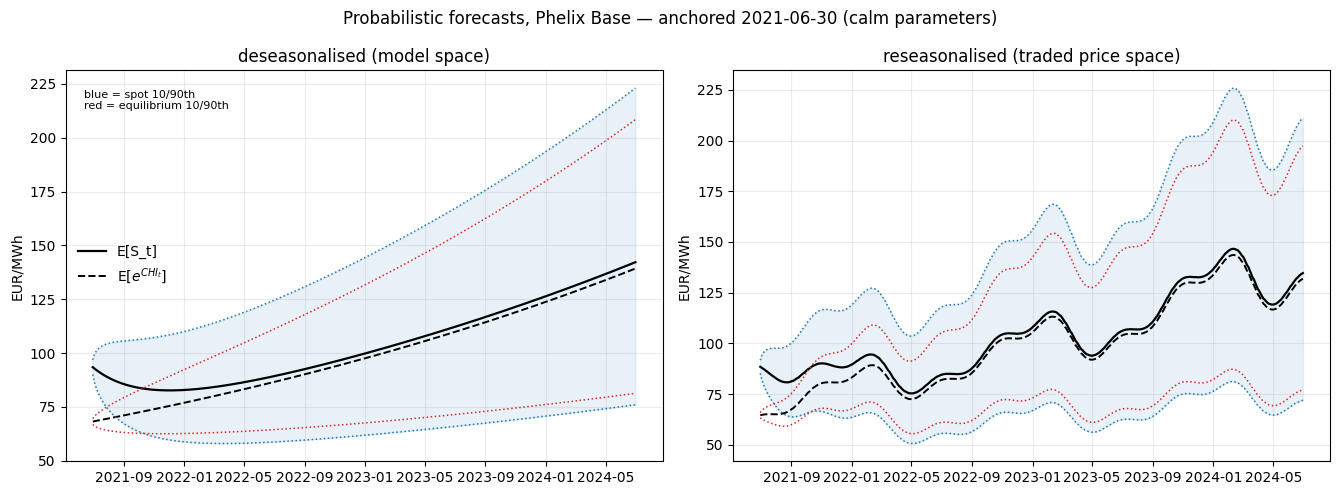

In [21]:
# --------------------------------------------------------------------------
# Figure 1 -- probabilistic forecasts for spot and equilibrium prices
# --------------------------------------------------------------------------
tg  = np.linspace(1e-4, HORIZON, 400)
cal = t0 + pd.to_timedelta(tg*365.25, unit='D')
m, v = logspot_moments(tg, p, X0, CHI0, 'P', Chat)
Vc   = state_cov(tg, p, Chat)
mc, vc = CHI0 + p.mu_xi*tg, Vc[:, 1, 1]
g    = gfun(cal)
 
fig, ax = plt.subplots(1, 2, figsize=(13.5, 5), sharey=False)
for k, (add, ttl) in enumerate([(0.0, 'deseasonalised (model space)'),
                                (g,  'reseasonalised (traded price space)')]):
    a = ax[k]
    a.plot(cal, np.exp(m + .5*v + add), 'k-',  lw=1.6, label='E[S_t]')
    a.plot(cal, np.exp(mc + .5*vc + add), 'k--', lw=1.4, label=r'E[$e^{CHI_t}$]')
    for q, ls in [(.9, ':'), (.1, ':')]:
        z = norm.ppf(q)
        a.plot(cal, np.exp(m + z*np.sqrt(v) + add), 'C0'+ls, lw=1.1)
        a.plot(cal, np.exp(mc + z*np.sqrt(vc) + add), 'C3'+ls, lw=1.1)
    a.fill_between(cal, np.exp(m+norm.ppf(.1)*np.sqrt(v)+add),
                   np.exp(m+norm.ppf(.9)*np.sqrt(v)+add), color='C0', alpha=.10)
    a.set_title(ttl); a.set_ylabel('EUR/MWh'); a.grid(alpha=.25)
ax[0].legend(frameon=False)
ax[0].text(.03, .95, 'blue = spot 10/90th\nred = equilibrium 10/90th',
           transform=ax[0].transAxes, va='top', fontsize=8)
fig.suptitle(f'Probabilistic forecasts, Phelix Base — anchored {t0.date()} '
             f'({WINDOW.split("/")[-1]} parameters)')
plt.tight_layout(); 
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/fig1_probabilistic_forecasts.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [22]:
# ===========================================================================
# CELL: futures valuation (Eq 9), Figure 2 and Figure 3
# Run after the process cell.
# ===========================================================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt
 
# --------------------------------------------------------------------------
# ln F_{T,0} = E*[ln S_T] + 1/2 Var*[ln S_T] = e^{-kappa T} X_0 + CHI_0 + A(T)
# --------------------------------------------------------------------------
def log_futures_pt(T, p, X0, CHI0):
    T = np.atleast_1d(np.asarray(T, float))
    return np.exp(-p.kappa*T)*X0 + CHI0 + A(T, p)
 
def log_futures_flow(U_, W_, p, X0, CHI0):
    """Geometric delivery average -- the quantity actually quoted on EEX."""
    Up = np.where(W_ > 0, U_, 1.0)
    return (W_*np.exp(-p.kappa*Up)).sum(-1)*X0 + CHI0 + (W_*A(Up, p)).sum(-1)
 
def sigma_phi(t, T, p):
    """sd of ln F_{T,t} seen from time 0 -- Sec 3.2.  Feeds the option cell."""
    t, T = np.atleast_1d(np.asarray(t, float)), np.asarray(T, float)
    k, sx, sc, r = p.kappa, p.sigma_chi, p.sigma_xi, p.rho
    return np.sqrt(np.exp(-2*k*(T-t))*(1-np.exp(-2*k*t))*sx**2/(2*k)
                   + sc**2*t
                   + 2*np.exp(-k*(T-t))*(1-np.exp(-k*t))*r*sx*sc/k)
 
def inst_vol(T, p):
    """Instantaneous vol of ln F_{T,0}; -> sqrt(sx^2+sc^2+2 r sx sc) at T=0,
       -> sigma_CHI as T -> inf."""
    T = np.atleast_1d(np.asarray(T, float))
    k, sx, sc, r = p.kappa, p.sigma_chi, p.sigma_xi, p.rho
    return np.sqrt(np.exp(-2*k*T)*sx**2 + sc**2 + 2*np.exp(-k*T)*r*sx*sc)
 
def asymptote_lines(p, X0, CHI0):
    """(intercept, slope) of the long-run lines -- Eq (6) and Sec 3.1."""
    base = CHI0 + p.sigma_chi**2/(4*p.kappa) + p.rho*p.sigma_chi*p.sigma_xi/p.kappa
    return ((base,                          p.mu_xi      + .5*p.sigma_xi**2),
            (base - p.lambda_chi/p.kappa,   p.mu_xi_star + .5*p.sigma_xi**2))
 
assert np.allclose(log_futures_pt([1e-9], p, X0, CHI0)[0], X0 + CHI0, atol=1e-6)
assert abs(inst_vol([40.0], p)[0] - p.sigma_xi) < 1e-6

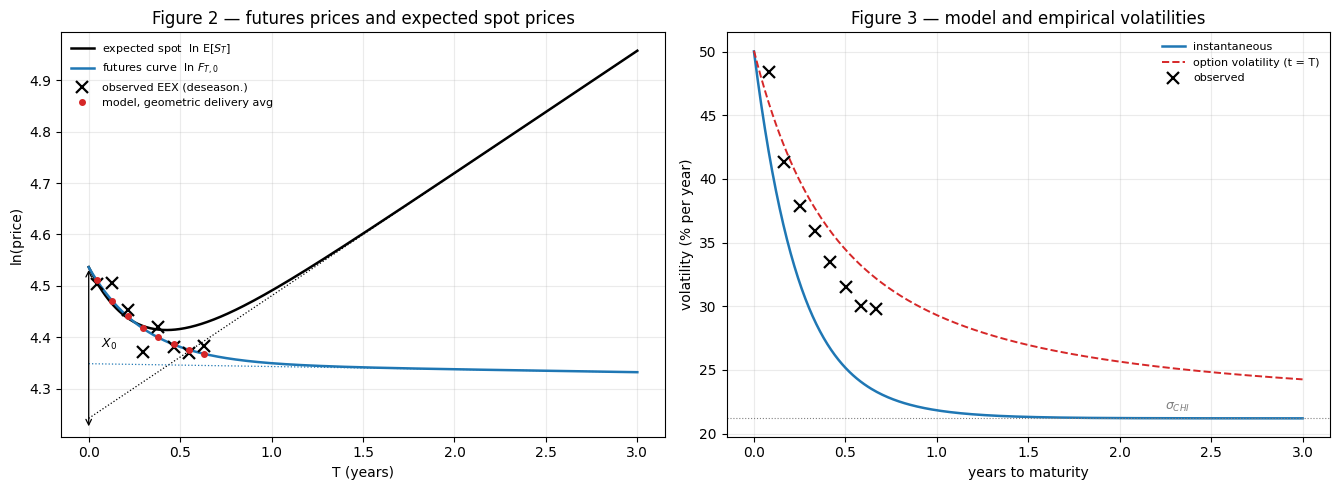

curve fit on 2021-06-30 :  RMSE = 0.02303 log pts (2.30%)   MAE = 0.01846
T=0 spot vol 50.1%   sigma_CHI 21.2%   half-life 2.43 months


In [23]:
# --------------------------------------------------------------------------
# Figure 2 -- futures curve vs expected spot prices
# --------------------------------------------------------------------------
Tg   = np.linspace(1e-4, HORIZON, 400)
lnF  = log_futures_pt(Tg, p, X0, CHI0)
lnES = log_expected_spot(Tg, p, X0, CHI0, 'P', Chat)
(ia, sa), (ib, sb) = asymptote_lines(p, X0, CHI0)
 
obs_tau  = tau[ANCHOR]
obs_lnF  = y[ANCHOR]                                   # deseasonalised, geometric
fit_lnF  = log_futures_flow(U[ANCHOR], W[ANCHOR], p, X0, CHI0)
 
fig, ax = plt.subplots(1, 2, figsize=(13.5, 5))
a = ax[0]
a.plot(Tg, lnES, 'k-',  lw=1.8, label='expected spot  ln E[$S_T$]')
a.plot(Tg, lnF,  'C0-', lw=1.8, label='futures curve  ln $F_{T,0}$')
a.plot(Tg, ia + sa*Tg, 'k:',  lw=.9)
a.plot(Tg, ib + sb*Tg, 'C0:', lw=.9)
a.plot(obs_tau, obs_lnF, 'kx', ms=8, mew=1.6, label='observed EEX (deseason.)')
a.plot(obs_tau, fit_lnF, 'C3o', ms=4, label='model, geometric delivery avg')
a.annotate('', xy=(0, X0+CHI0), xytext=(0, CHI0),
           arrowprops=dict(arrowstyle='<->', lw=.9))
a.text(.05, (X0+2*CHI0)/2, ' $X_0$', fontsize=9)
a.set_xlabel('T (years)'); a.set_ylabel('ln(price)')
a.set_title('Figure 2 — futures prices and expected spot prices')
a.legend(frameon=False, fontsize=8); a.grid(alpha=.25)

# --------------------------------------------------------------------------
# Figure 3 -- model vs empirical volatilities
# --------------------------------------------------------------------------
same = TICK[1:] == TICK[:-1]
r    = np.diff(y, axis=0)/np.sqrt(dtv)[:, None]
obs_v = np.array([np.nanstd(np.where(same[:, i], r[:, i], np.nan))
                  for i in range(n)])
Tv   = np.linspace(1e-3, HORIZON, 300)
a = ax[1]
a.plot(Tv, 100*inst_vol(Tv, p),        'C0-', lw=1.8, label='instantaneous')
a.plot(Tv, 100*sigma_phi(Tv, Tv, p)/np.sqrt(Tv), 'C3--', lw=1.4,
       label='option volatility (t = T)')
a.plot(np.median(tau, 0), 100*obs_v, 'kx', ms=8, mew=1.6, label='observed')
a.axhline(100*p.sigma_xi, color='grey', lw=.8, ls=':')
a.text(HORIZON*.75, 100*p.sigma_xi*1.03, r'$\sigma_{CHI}$', color='grey', fontsize=9)
a.set_xlabel('years to maturity'); a.set_ylabel('volatility (% per year)')
a.set_title('Figure 3 — model and empirical volatilities')
a.legend(frameon=False, fontsize=8); a.grid(alpha=.25)
plt.tight_layout();
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/fig2_fig3_futures_and_vol.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
 
print('curve fit on %s :  RMSE = %.5f log pts (%.2f%%)   MAE = %.5f'
      % (t0.date(), np.sqrt(((obs_lnF-fit_lnF)**2).mean()),
         100*np.sqrt(((obs_lnF-fit_lnF)**2).mean()), np.abs(obs_lnF-fit_lnF).mean()))
print('T=0 spot vol %.1f%%   sigma_CHI %.1f%%   half-life %.2f months'
      % (100*inst_vol([1e-9], p)[0], 100*p.sigma_xi, 12*p.half_life))

--- calm
   start 0: NM   -2526.6431 -> BFGS   -2526.6431
    126s   -log L = -2526.6431

--- post
   start 0: NM   -2372.7905 -> BFGS   -2372.7905
   start 1: NM   -2372.7905 -> BFGS   -2372.7905
    259s   -log L = -2372.7905

--- full
   start 0: NM   -4792.3992 -> BFGS   -4792.3992
   start 1: NM   -4792.3992 -> BFGS   -4792.3992
   start 2: NM   -4792.3992 -> BFGS   -4792.3992
   start 3: NM   -4792.3992 -> BFGS   -4792.3992
    1272s   -log L = -4792.3992


Maximum-likelihood estimates (standard errors in parentheses)

                         calm               post               full
kappa        3.4172\n(0.3285)   1.6455\n(0.2984)   1.1349\n(0.1980)
sigma_chi    0.3568\n(0.0337)   0.4813\n(0.0577)   0.8027\n(0.0909)
lambda_chi  -0.3630\n(0.1971)   0.1472\n(0.2637)  -0.6154\n(0.2922)
mu_xi        0.2156\n(0.1136)  -0.2749\n(0.1961)   0.0927\n(0.1694)
sigma_xi     0.2120\n(0.0166)   0.3664\n(0.0327)   0.4962\n(0.0516)
mu_xi_star  -0.0280\n(0.0211)   0.0196\n(0.0453)  -0.4871\n(0

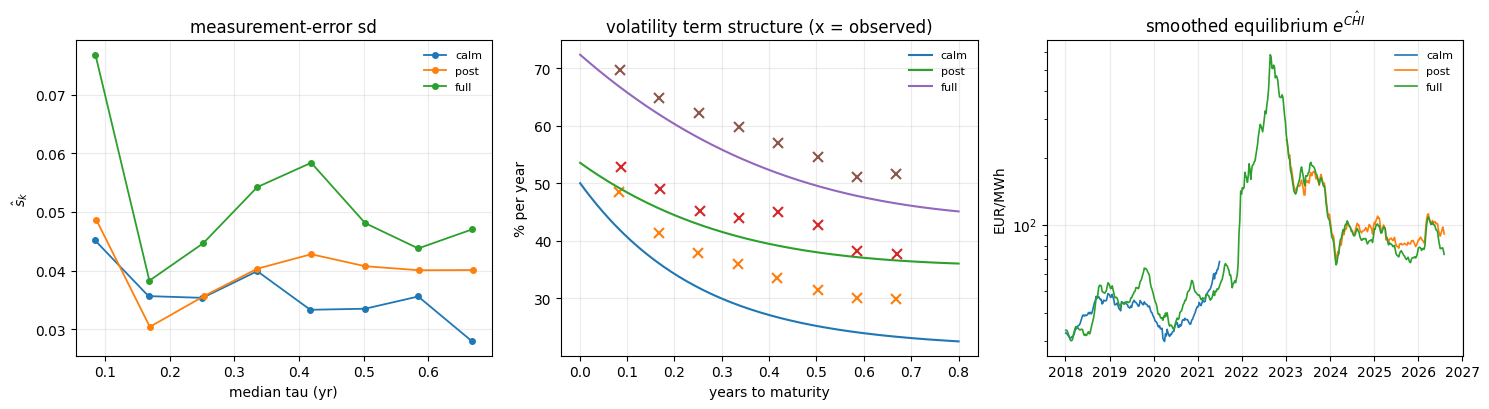

In [24]:
# ===========================================================================
# CELL: fit calm / post / full and compare.  Requires Params and A(T, p).
# ===========================================================================
import sys, time, numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, 'prepped')
import ss_fit as F
from ss_flow import load_window, seasonal_g

SPECS = [('calm', 1), ('post', 2), ('full', 4)]     # (window, n_starts)

fits = {}
for w, ns in SPECS:
    t0 = time.time()
    print(f'--- {w}')
    ctx = F.make_ctx(load_window(f'prepped/{w}'), A, Params)
    o   = F.estimate(ctx, n_starts=ns, seed=0)
    o['ctx'], o['secs'] = ctx, time.time() - t0
    fits[w] = o
    print(f'    {o["secs"]:.0f}s   -log L = {o["nll"]:.4f}\n')

# --------------------------------------------------------------------------
# side-by-side parameter table
# --------------------------------------------------------------------------
def col(o):
    est = np.r_[[getattr(o['p'], f) for f in F.PNAMES], o['s']]
    return [f'{e:.4f}\n({s:.4f})' for e, s in zip(est, o['se'])]

n   = fits['calm']['ctx']['n']
idx = F.PNAMES + [f's_{i+1}' for i in range(n)]
cmp_tbl = pd.DataFrame({w: col(fits[w]) for w, _ in SPECS}, index=idx)

foot = pd.DataFrame({w: [
    f"{fits[w]['ctx']['n_T']}",
    f"{fits[w]['ctx']['dates'][0].date()} to {fits[w]['ctx']['dates'][-1].date()}",
    f"{fits[w]['nll']:.1f}",
    f"{12*fits[w]['p'].half_life:.2f} mo",
    f"{fits[w]['p'].lambda_xi:+.4f}",
    f"{100*np.sqrt(np.exp(-2*fits[w]['p'].kappa*1e-9)*fits[w]['p'].sigma_chi**2 + fits[w]['p'].sigma_xi**2 + 2*fits[w]['p'].rho*fits[w]['p'].sigma_chi*fits[w]['p'].sigma_xi):.1f}%",
    f"{np.abs(fits[w]['V']).mean():.4f}",
    f"{fits[w]['eig'].min():.2e}",
] for w, _ in SPECS},
    index=['observations', 'sample', '-log L', 'half-life of X',
           'lambda_CHI', 'T=0 spot vol', 'mean |error|', 'min Hessian eig'])

print('\nMaximum-likelihood estimates (standard errors in parentheses)\n')
print(cmp_tbl.to_string())
print('\n', foot.to_string())

# --------------------------------------------------------------------------
# visual comparison: measurement errors and volatility term structure
# --------------------------------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
for w, _ in SPECS:
    o, c = fits[w], fits[w]['ctx']
    p = o['p']
    tb = np.median(c['tau'], 0)
    ax[0].plot(tb, o['s'], 'o-', lw=1.3, ms=4, label=w)
    Tv = np.linspace(1e-3, .8, 200)
    iv = np.sqrt(np.exp(-2*p.kappa*Tv)*p.sigma_chi**2 + p.sigma_xi**2
                 + 2*np.exp(-p.kappa*Tv)*p.rho*p.sigma_chi*p.sigma_xi)
    ax[1].plot(Tv, 100*iv, lw=1.5, label=w)
    same = c['tick'][1:] == c['tick'][:-1]
    r = np.diff(c['y'], axis=0)/np.sqrt(c['dtv'])[:, None]
    ax[1].plot(tb, 100*np.array([np.nanstd(np.where(same[:, i], r[:, i], np.nan))
                                 for i in range(c['n'])]), 'x', ms=7, mew=1.5)
    ax[2].plot(c['dates'], np.exp(o['xi_s']), lw=1.2, label=w)
ax[0].set(xlabel='median tau (yr)', ylabel=r'$\hat s_k$', title='measurement-error sd')
ax[1].set(xlabel='years to maturity', ylabel='% per year',
          title='volatility term structure (x = observed)')
ax[2].set(ylabel='EUR/MWh', title=r'smoothed equilibrium $e^{\hat{CHI}}$')
ax[2].set_yscale('log')
for a in ax: a.legend(frameon=False, fontsize=8); a.grid(alpha=.25)
plt.tight_layout(); 
import os
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/comparison_three_windows.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

100 replications on 15 workers (fresh_seed=False) ...


  5/100     73s elapsed, ~1387s left
  10/100     79s elapsed, ~ 710s left
  15/100     91s elapsed, ~ 515s left
  20/100    134s elapsed, ~ 535s left
  25/100    142s elapsed, ~ 426s left
  30/100    179s elapsed, ~ 419s left
  35/100    196s elapsed, ~ 365s left
  40/100    211s elapsed, ~ 316s left
  45/100    237s elapsed, ~ 290s left
  50/100    258s elapsed, ~ 258s left
  55/100    279s elapsed, ~ 228s left
  60/100    302s elapsed, ~ 201s left
  65/100    321s elapsed, ~ 173s left
  70/100    354s elapsed, ~ 152s left
  75/100    369s elapsed, ~ 123s left
  80/100    399s elapsed, ~ 100s left
  85/100    431s elapsed, ~  76s left
  90/100    439s elapsed, ~  49s left
  95/100    459s elapsed, ~  24s left
  100/100    466s elapsed, ~   0s left

100/100 replications succeeded in 466s (4.7s per replication)

               true  mc_mean     bias    mc_sd  hessian_se  sd_ratio  |t_bias|
kappa       1.13492  1.17023  0.03531  0.16629     0.19804   0.83966   2.12363
sigma_chi   0.8026

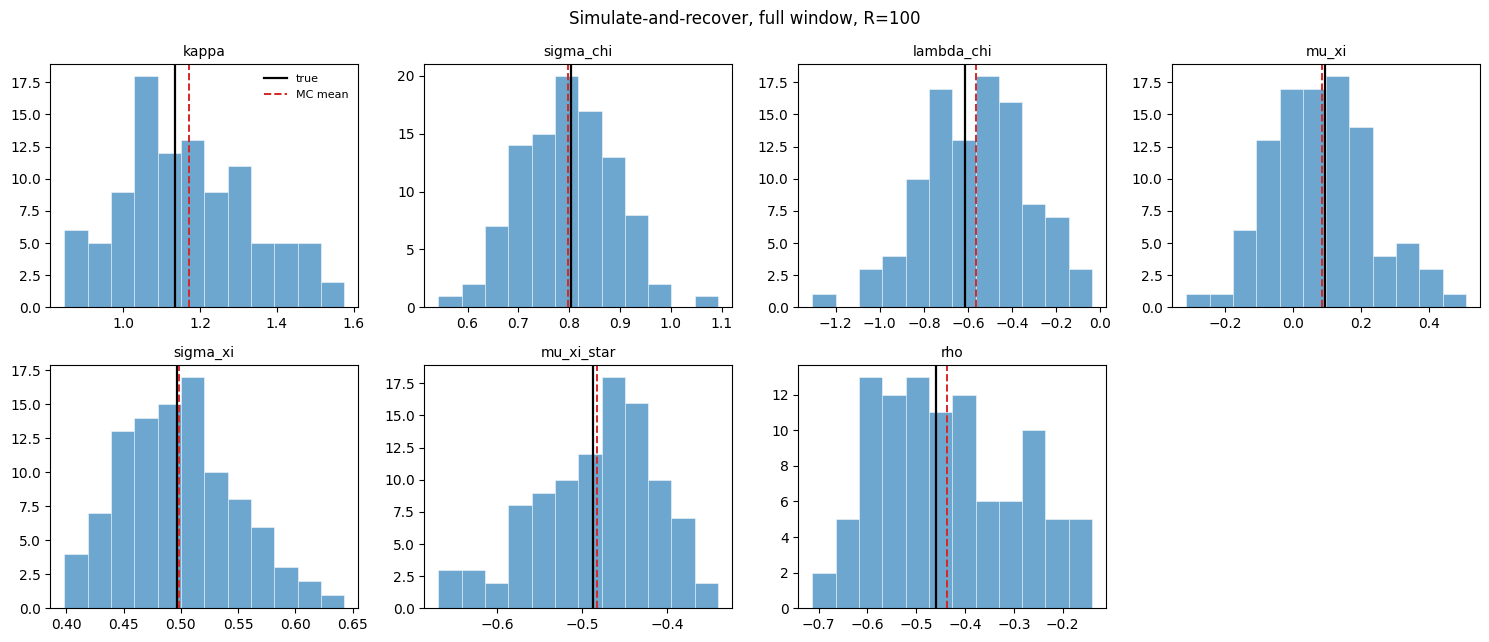

In [25]:
# ===========================================================================
# CELL: parallel simulate-and-recover Monte Carlo on the FULL window
# Needs mc_worker.py beside ss_fit.py / ss_flow.py, and `fits` for the SEs.
# ===========================================================================
import sys, os, time, numpy as np, pandas as pd, matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed
sys.path.insert(0, 'prepped')
import ss_fit as F
from mc_worker import run_rep

R           = 100
SEED        = 12345
WINDOW      = 'prepped/full'
FRESH_SEED  = False        # False: start each refit at theta_hat (fast)
                           # True : re-run the MoM seed each time (~40x slower)
MAX_WORKERS = max(1, (os.cpu_count() or 2) - 1)

o_full  = fits['full']
th_true = tuple(o_full['theta'])
n       = o_full['ctx']['n']
idx     = F.PNAMES + [f's_{i+1}' for i in range(n)]
true    = np.r_[[getattr(o_full['p'], f) for f in F.PNAMES], o_full['s']]

jobs = [(WINDOW, th_true, SEED + i, FRESH_SEED) for i in range(R)]
print(f'{R} replications on {MAX_WORKERS} workers '
      f'(fresh_seed={FRESH_SEED}) ...', flush=True)

rows, done, t0 = [], 0, time.time()
with ProcessPoolExecutor(max_workers=MAX_WORKERS) as ex:
    futs = [ex.submit(run_rep, j) for j in jobs]
    for f in as_completed(futs):
        r = f.result()
        if r is not None:
            rows.append(r)
        done += 1
        if done % 5 == 0 or done == R:
            el = time.time() - t0
            print(f'  {done}/{R}  {el:>5.0f}s elapsed, '
                  f'~{el/done*(R-done):>4.0f}s left', flush=True)

M = np.array(rows)
mc = pd.DataFrame({
    'true'      : true,
    'mc_mean'   : M.mean(0),
    'bias'      : M.mean(0) - true,
    'mc_sd'     : M.std(0, ddof=1),
    'hessian_se': o_full['se'],
}, index=idx)
mc['sd_ratio'] = mc.mc_sd / mc.hessian_se
mc['|t_bias|'] = np.abs(mc.bias) / (mc.mc_sd/np.sqrt(len(M)))

print(f'\n{len(M)}/{R} replications succeeded in {time.time()-t0:.0f}s '
      f'({(time.time()-t0)/R:.1f}s per replication)\n')
print(mc.round(5).to_string())
print('\nsd_ratio > 1  =>  Hessian standard errors are too optimistic')
print('|t_bias| > 2  =>  significant finite-sample bias at this R')
np.save('mc_draws.npy', M)

fig, ax = plt.subplots(2, 4, figsize=(15, 6.5))
for i, a in enumerate(ax.ravel()):
    if i >= 7:
        a.axis('off'); continue
    a.hist(M[:, i], bins=max(8, len(M)//8), color='C0', alpha=.65,
           edgecolor='w', lw=.5)
    a.axvline(true[i],       color='k',  lw=1.6, label='true')
    a.axvline(M[:, i].mean(), color='C3', lw=1.4, ls='--', label='MC mean')
    a.set_title(idx[i], fontsize=10)
    if i == 0: a.legend(frameon=False, fontsize=8)
fig.suptitle(f'Simulate-and-recover, full window, R={len(M)}')
plt.tight_layout();
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/monte_carlo_recovery.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()